# E — GOP learned scoring

Reads artifacts from Group E. **Does not recompute GOP** and **does not train**.

| File | Experiment |
| --- | --- |
| `outputs/E/e_predictions.csv` | B4 (default) features + `pred_e1` / `pred_e2` |
| `outputs/E/e_c8_predictions.csv` | C8 GOP-S + `pred_e3` / `pred_e4` (after `--features c8`) |
| `outputs/E/e_c9_predictions.csv` | C9 GOP-S + `pred_e5` / `pred_e6` (after `--features c9`) |
| `outputs/E/e_b5_predictions.csv` | Kaldi 84-d + `pred_e7` / `pred_e8`; `pred_e13` / `pred_e14` after `--features b5_embed` |
| `outputs/E/e_c8_lpp_lpr_predictions.csv` | C8 78-d + `pred_e9` / `pred_e10`; `pred_e15` / `pred_e16` after `--features c8_lpp_lpr_embed` |
| `outputs/E/e_c9_lpp_lpr_predictions.csv` | C9 78-d + `pred_e11` / `pred_e12`; `pred_e17` / `pred_e18` after `--features c9_lpp_lpr_embed` |
| `outputs/E/e_results.json` | protocol, E1–E18 if run, frozen baselines |

```text
python scripts/run_experiment.py --config configs/e_learned_scoring.yaml
python scripts/run_experiment.py --config configs/e_learned_scoring.yaml --features a1
python scripts/run_experiment.py --config configs/e_learned_scoring.yaml --features c8 c9
python scripts/run_experiment.py --config configs/e_learned_scoring.yaml --features b5
python scripts/run_experiment.py --config configs/e_learned_scoring.yaml --features b5_embed
python scripts/extract_ssl_gop.py --config configs/c_acoustic_model.yaml --model xlsr_espeak --gop lpp_lpr
python scripts/extract_ssl_gop.py --config configs/c_acoustic_model.yaml --model lv60_espeak --gop lpp_lpr
python scripts/run_experiment.py --config configs/e_learned_scoring.yaml --features c8_lpp_lpr c9_lpp_lpr
python scripts/run_experiment.py --config configs/e_learned_scoring.yaml --features c8_lpp_lpr_embed c9_lpp_lpr_embed
```

E1 and E2 share Kaldi B4. E3/E4 share C8 Cao GOP-S; E5/E6 share C9. E7/E8 share 84-d; E13/E14 share the same 84-d plus phone embed. E9/E10 share C8 78-d; E15/E16 share the same 78-d plus SSL phone embed. E11/E12 share C9 78-d; E17/E18 share the same 78-d plus SSL embed. Fair pairs only. C8/C9 vectors are not 84-d. SSL embed uses 39 scored IPA ids, not Kaldi 42-slot.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "outputs" / "E" / "e_results.json").is_file():
    if (ROOT / "GOP-Empirical-Study" / "outputs" / "E" / "e_results.json").is_file():
        ROOT = ROOT / "GOP-Empirical-Study"
    elif (ROOT.parent / "outputs" / "E" / "e_results.json").is_file():
        ROOT = ROOT.parent

OUT = ROOT / "outputs" / "E"
results = json.loads((OUT / "e_results.json").read_text(encoding="utf-8"))
protocol = results["protocol"]
pred = pd.read_csv(OUT / "e_predictions.csv", dtype={"utt_id": str, "phone": str, "role": str})
print("ROOT", ROOT)
print(
    protocol["acoustic_model"],
    "features", protocol["features_requested"],
    "primary", results["feature_set"],
    "device", protocol["device"],
)
print(
    "speakers fit/val/test",
    protocol["n_speakers_train_fit"],
    protocol["n_speakers_val"],
    protocol["n_speakers_test"],
)
print("n roles", pred["role"].value_counts().to_dict())
print("E1 test PCC", round(results["E1"]["pcc"], 4), "E2", round(results["E2"]["pcc"], 4))
for eid in ("E3", "E4", "E5", "E6", "E7", "E8", "E9", "E10", "E11", "E12", "E13", "E14", "E15", "E16", "E17", "E18"):
    block = results.get(eid)
    if isinstance(block, dict) and "pcc" in block:
        print(eid, "test PCC", round(block["pcc"], 4))


ROOT d:\FSB_MSE\FINAL\GOP-Empirical-Study
kaldi_librispeech_m13 features ['c9_lpp_lpr', 'c9_lpp_lpr_embed'] primary b4 device cpu
speakers fit/val/test 100 25 125
n roles {'test': 47369, 'train': 37642, 'val': 9434}
E1 test PCC 0.3618 E2 0.5096
E3 test PCC 0.4961
E4 test PCC 0.5777
E5 test PCC 0.4474
E6 test PCC 0.4826
E7 test PCC 0.4462
E8 test PCC 0.5301
E9 test PCC 0.5731
E10 test PCC 0.6387
E11 test PCC 0.5481
E12 test PCC 0.6243
E13 test PCC 0.5518
E14 test PCC 0.6252
E15 test PCC 0.6366
E16 test PCC 0.6714
E17 test PCC 0.6178
E18 test PCC 0.6526


In [2]:
feature_set = results["feature_set"]
block = results[feature_set]
baseline = block["baseline"]
rows = [
    (baseline["name"], baseline["pcc"], baseline["scc"], baseline["mae"], baseline["mse"]),
    ("E1 MLP", results["E1"]["pcc"], results["E1"]["scc"], results["E1"]["mae"], results["E1"]["mse"]),
    ("E2 Transformer", results["E2"]["pcc"], results["E2"]["scc"], results["E2"]["mae"], results["E2"]["mse"]),
]
for fs, mlp_id, tf_id, mlp_label, tf_label in (
    ("c8", "E3", "E4", "E3 MLP", "E4 Transformer"),
    ("c9", "E5", "E6", "E5 MLP", "E6 Transformer"),
    ("b5", "E7", "E8", "E7 MLP", "E8 Transformer"),
    ("b5_embed", "E13", "E14", "E13 MLP+embed", "E14 Transformer+embed"),
    ("c8_lpp_lpr", "E9", "E10", "E9 MLP", "E10 Transformer"),
    ("c9_lpp_lpr", "E11", "E12", "E11 MLP", "E12 Transformer"),
    ("c8_lpp_lpr_embed", "E15", "E16", "E15 MLP+embed", "E16 Transformer+embed"),
    ("c9_lpp_lpr_embed", "E17", "E18", "E17 MLP+embed", "E18 Transformer+embed"),
):
    if fs not in results:
        continue
    ssl = results[fs]
    ssl_base = ssl["baseline"]
    rows.append((ssl_base["name"], ssl_base["pcc"], ssl_base["scc"], ssl_base["mae"], ssl_base["mse"]))
    rows.append((mlp_label, ssl[mlp_id]["pcc"], ssl[mlp_id]["scc"], ssl[mlp_id]["mae"], ssl[mlp_id]["mse"]))
    rows.append((tf_label, ssl[tf_id]["pcc"], ssl[tf_id]["scc"], ssl[tf_id]["mae"], ssl[tf_id]["mse"]))
table = pd.DataFrame(rows, columns=["model", "pcc", "scc", "mae", "mse"])
print(table.round(4).to_string(index=False))
print("baseline source", baseline["source"])


                model    pcc    scc    mae    mse
               b4_ols 0.3513 0.3418 0.1972 0.1196
               E1 MLP 0.3618 0.3265 0.1921 0.1182
       E2 Transformer 0.5096 0.3678 0.1580 0.1001
            direct_c8 0.4632 0.3548 0.1729 0.1078
               E3 MLP 0.4961 0.3548 0.1672 0.1031
       E4 Transformer 0.5777 0.3611 0.1539 0.0900
            direct_c9 0.4299 0.3339 0.1789 0.1122
               E5 MLP 0.4474 0.3336 0.1624 0.1100
       E6 Transformer 0.4826 0.3187 0.1568 0.1050
               b5_ols 0.3614 0.3322 0.1971 0.1186
               E7 MLP 0.4462 0.3496 0.1684 0.1085
       E8 Transformer 0.5301 0.3787 0.1540 0.0971
               b5_ols 0.3614 0.3322 0.1971 0.1186
        E13 MLP+embed 0.5518 0.3589 0.1591 0.0941
E14 Transformer+embed 0.6252 0.4028 0.1484 0.0825
       c8_lpp_lpr_ols 0.5069 0.3581 0.1725 0.1018
               E9 MLP 0.5731 0.3919 0.1424 0.0910
      E10 Transformer 0.6387 0.4149 0.1496 0.0802
       c9_lpp_lpr_ols 0.4816 0.3325 0.1766 0.1053


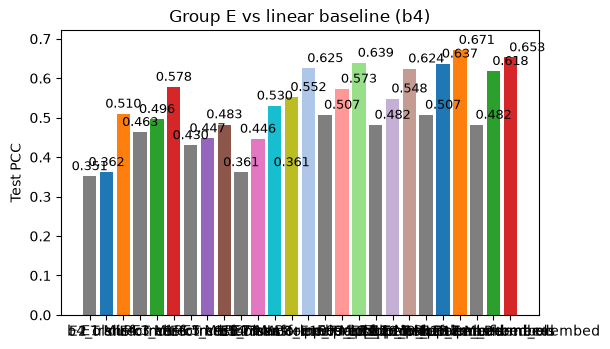

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
labels = table["model"].tolist()
values = table["pcc"].tolist()
colors = [
    "#7f7f7f", "#1f77b4", "#ff7f0e",
    "#7f7f7f", "#2ca02c", "#d62728",
    "#7f7f7f", "#9467bd", "#8c564b",
    "#7f7f7f", "#e377c2", "#17becf",
    "#7f7f7f", "#bcbd22", "#aec7e8",
    "#7f7f7f", "#ff9896", "#98df8a",
    "#7f7f7f", "#c5b0d5", "#c49c94",
]
ax.bar(labels, values, color=colors[: len(labels)])
ax.set_ylabel("Test PCC")
ax.set_ylim(0.0, max(0.5, max(values) + 0.05))
ax.set_title(f"Group E vs linear baseline ({feature_set})")
for i, v in enumerate(values):
    ax.text(i, v + 0.008, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "e_comparison_pcc.png", dpi=140)
plt.show()


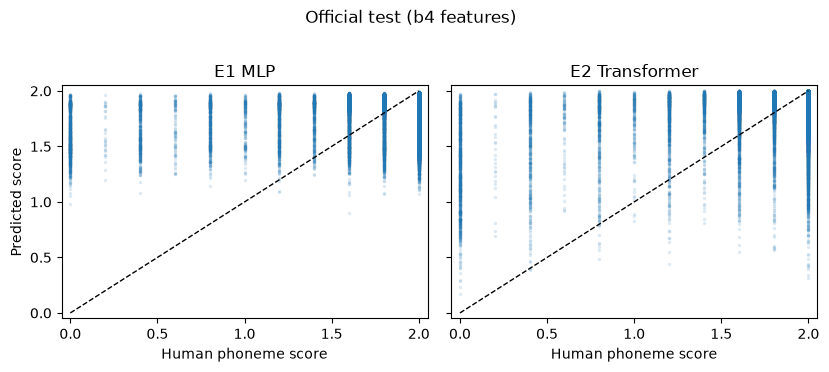

also e_c8_predictions.csv columns ['utt_id', 'split', 'role', 'word_id', 'phone_id', 'phone', 'speaker', 'human_score', 'feat_gop_c8', 'pred_e3', 'pred_e4']
also e_c9_predictions.csv columns ['utt_id', 'split', 'role', 'word_id', 'phone_id', 'phone', 'speaker', 'human_score', 'feat_gop_c9', 'pred_e5', 'pred_e6']
also e_b5_predictions.csv columns ['utt_id', 'split', 'role', 'word_id', 'phone_id', 'phone', 'speaker', 'human_score', 'pred_e7', 'pred_e8', 'pred_e13', 'pred_e14']
also e_c8_lpp_lpr_predictions.csv columns ['utt_id', 'split', 'role', 'word_id', 'phone_id', 'phone', 'speaker', 'human_score', 'pred_e9', 'pred_e10', 'pred_e15', 'pred_e16']
also e_c9_lpp_lpr_predictions.csv columns ['utt_id', 'split', 'role', 'word_id', 'phone_id', 'phone', 'speaker', 'human_score', 'pred_e11', 'pred_e12', 'pred_e17', 'pred_e18']


In [4]:
test = pred[pred["role"] == "test"]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6), sharex=True, sharey=True)
for ax, col, title in (
    (axes[0], "pred_e1", "E1 MLP"),
    (axes[1], "pred_e2", "E2 Transformer"),
):
    ax.scatter(test["human_score"], test[col], s=6, alpha=0.15, c="#1f77b4", linewidths=0)
    ax.plot([0, 2], [0, 2], color="black", lw=1, ls="--")
    ax.set_xlabel("Human phoneme score")
    ax.set_title(title)
    ax.set_xlim(-0.05, 2.05)
    ax.set_ylim(-0.05, 2.05)
axes[0].set_ylabel("Predicted score")
fig.suptitle(f"Official test ({feature_set} features)", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "e_scatter_pred_vs_human.png", dpi=140)
plt.show()
for name in (
    "e_c8_predictions.csv",
    "e_c9_predictions.csv",
    "e_b5_predictions.csv",
    "e_c8_lpp_lpr_predictions.csv",
    "e_c9_lpp_lpr_predictions.csv",
):
    path = OUT / name
    if path.is_file():
        print("also", path.name, "columns", list(pd.read_csv(path, nrows=0).columns))
